# Визуализация на Python — практический конспект

Этот ноутбук — практическое дополнение к конспекту. Здесь весь код можно **запускать и смотреть результат**. Каждый пример сопровождается подробным разбором: что делает каждая строка и как это воспроизвести самостоятельно.

**Как пользоваться:**
1. Запусти ячейки по порядку сверху вниз (первая ячейка создаёт датасет).
2. Читай разбор **над** каждым блоком кода.
3. Меняй параметры и смотри, что изменится — это лучший способ закрепить.

**Структура:**
- 0 — Датасет (генерируется автоматически)
- 1 — Подготовка данных
- 2 — pandas.plot (быстрые графики)
- 3 — Matplotlib (фундамент)
- 4 — Seaborn (статистика)
- 5 — Plotly (интерактив)
- 6 — Выбор графика под задачу
- 7 — Мини-проект

---

## 0. Датасет

Работать будем на синтетическом датасете продаж интернет-магазина за 2024 год — **10 000 строк**. Он генерируется кодом ниже, поэтому ничего скачивать не нужно.

**Что заложено в данные (специально, чтобы графики были осмысленными):**
- **Правый хвост** в суммах заказа (`amount`) — много мелких покупок и несколько очень крупных. Это типично для реальных продаж и хорошо видно на гистограмме.
- **Сезонность** — лёгкий рост к концу года и всплеск в декабре. Видно на линейном графике.
- **Связь** между рекламным бюджетом (`ad_budget`) и суммой заказа — для scatter и корреляций.
- **Разные сегменты** (Новый / Постоянный / VIP) — VIP покупают дороже.
- **Пропуски** в `ad_budget` (~2%) — чтобы потренировать обработку.

**Колонки:**

| Колонка | Тип | Описание |
|---|---|---|
| `order_id` | int | ID заказа |
| `date` | datetime | Дата заказа |
| `category` | str | Категория товара (8 шт.) |
| `region` | str | Регион (5 шт.) |
| `segment` | str | Сегмент клиента |
| `channel` | str | Канал продажи |
| `manager` | str | Менеджер (8 шт.) |
| `quantity` | int | Количество товаров |
| `amount` | float | Сумма заказа, руб. |
| `ad_budget` | float | Рекламный бюджет на заказ, руб. (есть пропуски) |
| `discount_pct` | int | Скидка, % |

In [57]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn plotly nbformat openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [58]:
import numpy, pandas, matplotlib, seaborn, plotly, nbformat
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("seaborn", seaborn.__version__)
print("plotly", plotly.__version__)
print("Python:", __import__('sys').version)

numpy 2.4.6
pandas 3.0.3
seaborn 0.13.2
plotly 6.7.0
Python: 3.13.13 (v3.13.13:01104ce1beb, Apr  7 2026, 14:43:30) [Clang 16.0.0 (clang-1600.0.26.6)]


In [59]:
import sys
!{sys.executable} -m pip install scikit-learn scipy jupyterlab ipykernel statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [60]:
# Генерация датасета. Запусти эту ячейку первой.
import numpy as np
import pandas as pd

np.random.seed(42)  # фиксируем случайность, чтобы у тебя были те же числа
N = 10000

# --- Даты за 2024 год ---
start = pd.Timestamp('2024-01-01')
days = np.random.randint(0, 366, N)
dates = start + pd.to_timedelta(days, unit='D')

# --- Категории с разными весами (Электроника встречается чаще) ---
categories = ['Электроника', 'Одежда', 'Дом и сад', 'Книги', 'Спорт',
              'Красота', 'Игрушки', 'Продукты']
category = np.random.choice(categories, N, p=[0.22, 0.18, 0.14, 0.08, 0.12, 0.10, 0.06, 0.10])

# --- Регионы, сегменты, каналы, менеджеры ---
region = np.random.choice(['Москва', 'Санкт-Петербург', 'Екатеринбург', 'Новосибирск', 'Казань'],
                          N, p=[0.35, 0.22, 0.15, 0.16, 0.12])
segment = np.random.choice(['Новый', 'Постоянный', 'VIP'], N, p=[0.45, 0.40, 0.15])
channel = np.random.choice(['Сайт', 'Мобильное приложение', 'Маркетплейс'], N, p=[0.40, 0.35, 0.25])
manager = np.random.choice([f'Менеджер {i}' for i in range(1, 9)], N)

# --- Сумма заказа: базовая цена категории * лог-нормальный множитель ---
cat_base = {'Электроника': 25000, 'Одежда': 4000, 'Дом и сад': 6000, 'Книги': 800,
            'Спорт': 5000, 'Красота': 2500, 'Игрушки': 2000, 'Продукты': 1500}
base = np.array([cat_base[c] for c in category])
amount = base * np.random.lognormal(0, 0.6, N)          # лог-нормальное -> правый хвост

# VIP покупают дороже
amount *= np.where(segment == 'VIP', 1.8, np.where(segment == 'Постоянный', 1.15, 1.0))

# Сезонность: тренд вверх + всплеск в декабре + лето
month = dates.month
amount *= (1 + 0.015 * (month - 1)
           + np.where(month == 12, 0.35, 0)
           + np.where(month.isin([6, 7]), 0.10, 0))
amount = np.round(amount, 0)

# --- Прочие колонки ---
quantity = np.random.choice([1, 1, 1, 2, 2, 3, 4], N)
ad_budget = np.clip(amount * np.random.uniform(0.05, 0.20, N) + np.random.normal(0, 500, N), 0, None).round(0)
discount = np.random.choice([0, 0, 0, 5, 10, 15, 20], N)

df = pd.DataFrame({
    'order_id': range(1, N + 1), 'date': dates, 'category': category,
    'region': region, 'segment': segment, 'channel': channel, 'manager': manager,
    'quantity': quantity, 'amount': amount, 'ad_budget': ad_budget, 'discount_pct': discount,
})

# Добавим немного пропусков в ad_budget (реалистично)
df.loc[np.random.choice(N, int(N * 0.02), replace=False), 'ad_budget'] = np.nan

df = df.sort_values('date').reset_index(drop=True)
print(f"Готово: {len(df)} строк")
df.head()

Готово: 10000 строк


,order_id,date,category,region,segment,channel,manager,quantity,amount,ad_budget,discount_pct
0,1031,2024-01-01,Электроника,Москва,Новый,Маркетплейс,Менеджер 2,1,12919.0,1003.0,20
1,994,2024-01-01,Красота,Екатеринбург,Новый,Мобильное приложение,Менеджер 5,1,2463.0,448.0,5
2,3590,2024-01-01,Спорт,Москва,Постоянный,Мобильное приложение,Менеджер 6,4,944.0,319.0,0
3,9712,2024-01-01,Красота,Екатеринбург,Постоянный,Маркетплейс,Менеджер 8,1,1674.0,0.0,15
4,6041,2024-01-01,Электроника,Санкт-Петербург,Новый,Маркетплейс,Менеджер 2,3,39858.0,NaN,5


**Разбор генерации (не обязательно к запоминанию, но полезно понимать):**

- `np.random.seed(42)` — фиксирует генератор случайных чисел. Благодаря этому у тебя получатся **ровно те же** числа, что в разборе ниже.
- `np.random.choice(values, N, p=[...])` — выбирает `N` случайных значений из `values` с заданными вероятностями `p`. Так мы делаем одни категории частыми, другие редкими.
- `np.random.lognormal(0, 0.6, N)` — лог-нормальное распределение. Оно даёт **правый хвост**: большинство значений небольшие, но есть редкие очень большие. Именно так выглядят реальные суммы заказов.
- `np.where(условие, A, B)` — векторный аналог `if`: где условие истинно, берёт `A`, иначе `B`. Используем для наценки VIP и сезонности.

Дальше работаем с готовым `df`.

In [61]:
# Сохраним датасет в CSV — пригодится, если захочешь перезапустить ноутбук с этого места
df.to_csv('sales.csv', index=False)

# Если ноутбук перезапущен и df потерян — раскомментируй строку ниже:
# df = pd.read_csv('sales.csv', parse_dates=['date'])

print("Датасет сохранён в sales.csv")

Датасет сохранён в sales.csv


---

## 1. Подготовка данных

> **Главное правило:** сначала готовим таблицу, потом строим график. Код графика должен быть простым.

Графики почти никогда не строятся на сырых 10 000 строк. Сначала данные **группируют и агрегируют**.

### 1.1. Базовая разведка

Прежде чем строить что-либо, смотрим на данные: типы, пропуски, диапазоны.

In [62]:
# .info() — типы колонок и пропуски
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      10000 non-null  int64         
 1   date          10000 non-null  datetime64[us]
 2   category      10000 non-null  str           
 3   region        10000 non-null  str           
 4   segment       10000 non-null  str           
 5   channel       10000 non-null  str           
 6   manager       10000 non-null  str           
 7   quantity      10000 non-null  int64         
 8   amount        10000 non-null  float64       
 9   ad_budget     9800 non-null   float64       
 10  discount_pct  10000 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 859.5 KB


In [63]:
# .describe() — статистика по числовым колонкам
# Обрати внимание: для amount mean (среднее) сильно больше median (50%) —
# это признак правого хвоста (несколько очень крупных заказов тянут среднее вверх)
df.describe()

,order_id,date,quantity,amount,ad_budget,discount_pct
count,10000.00000,10000,10000.000000,10000.000000,9800.000000,10000.000000
mean,5000.50000,2024-06-30 22:10:07.680000,1.998400,13324.326400,1707.617755,7.174000
min,1.00000,2024-01-01 00:00:00,1.000000,164.000000,0.000000,0.000000
25%,2500.75000,2024-04-02 00:00:00,1.000000,2614.250000,268.000000,0.000000
50%,5000.50000,2024-06-30 00:00:00,2.000000,5603.500000,812.000000,5.000000
75%,7500.25000,2024-10-01 00:00:00,3.000000,13970.500000,1849.250000,15.000000
max,10000.00000,2024-12-31 00:00:00,4.000000,247835.000000,45076.000000,20.000000
std,2886.89568,NaN,1.071313,20759.615464,2783.939169,7.505955


In [64]:
# Пропуски по колонкам
df.isna().sum()

order_id          0
date              0
category          0
region            0
segment           0
channel           0
manager           0
quantity          0
amount            0
ad_budget       200
discount_pct      0
dtype: int64

**Разбор:**
- `df.info()` показывает типы. Главное — `date` должен быть `datetime64`, а не `object` (строка). У нас уже так, потому что мы создавали даты через pandas.
- `df.describe()` даёт `mean`, `std`, `min`, квартили (`25%`, `50%`, `75%`), `max`. Сравни `mean` и `50%` (медиану) у `amount` — большой разрыв означает асимметрию.
- `df.isna().sum()` считает пропуски в каждой колонке. У нас ~200 пропусков в `ad_budget`.

### 1.2. Группировка и агрегация

Самая частая операция перед графиком — `groupby`.

In [65]:
# Сумма продаж по категориям, отсортированная
category_sales = (
    df
    .groupby('category', as_index=False)   # группируем по категории
    .agg(sales_sum=('amount', 'sum'))      # считаем сумму amount, называем колонку sales_sum
    .sort_values('sales_sum', ascending=False)
)
category_sales

,category,sales_sum
7,Электроника,90003352.0
0,Дом и сад,13844961.0
4,Одежда,11073455.0
6,Спорт,9190937.0
3,Красота,3804607.0
5,Продукты,2321404.0
1,Игрушки,1983120.0
2,Книги,1021428.0


**Разбор построчно:**
- `.groupby('category', as_index=False)` — группирует строки по категории. Параметр `as_index=False` оставляет `category` обычной колонкой (без него она стала бы индексом, и работать дальше было бы неудобно).
- `.agg(sales_sum=('amount', 'sum'))` — это синтаксис «named aggregation»: создать колонку `sales_sum`, равную сумме (`'sum'`) колонки `amount`. Можно перечислить несколько метрик через запятую.
- `.sort_values('sales_sum', ascending=False)` — сортировка по убыванию.

Этот результат — готовая таблица для bar chart.

In [66]:
# Несколько метрик сразу
summary = (
    df
    .groupby('segment', as_index=False)
    .agg(
        revenue=('amount', 'sum'),          # сумма
        orders=('order_id', 'nunique'),     # количество уникальных заказов
        avg_check=('amount', 'mean'),       # средний чек
        median_check=('amount', 'median'),  # медианный чек
    )
)
summary

,segment,revenue,orders,avg_check,median_check
0,VIP,29687442.0,1440,20616.279167,8651.5
1,Новый,51149313.0,4584,11158.227094,4851.0
2,Постоянный,52406509.0,3976,13180.711519,5683.0


**Разбор:** в одном `.agg()` можно посчитать сколько угодно метрик. Каждая — это пара `имя=('колонка', 'функция')`. Доступные функции: `'sum'`, `'mean'`, `'median'`, `'min'`, `'max'`, `'count'`, `'nunique'` (количество уникальных) и другие.

Снова обрати внимание: `avg_check` (среднее) заметно выше `median_check` (медианы) — правый хвост.

### 1.3. pivot_table — данные в широком формате

`pivot_table` разворачивает данные в таблицу «строки × колонки». Удобно для stacked bar и heatmap.

In [67]:
# Продажи: месяцы по строкам, сегменты по колонкам
df['month'] = df['date'].dt.month   # добавим колонку с номером месяца

pivot = df.pivot_table(
    index='month',      # что по строкам
    columns='segment',  # что по колонкам
    values='amount',    # что агрегируем
    aggfunc='sum',      # как агрегируем
    fill_value=0        # чем заполнять пустые ячейки
)
pivot.head()

segment,VIP,Новый,Постоянный
month,,,
1,2331535.0,4108791.0,4670648.0
2,1769115.0,3741685.0,3314098.0
3,3014759.0,3427796.0,3661167.0
4,2264650.0,4216331.0,4235333.0
5,2754303.0,4176525.0,4054652.0


**Разбор:**
- `index='month'` — значения этой колонки станут строками результата.
- `columns='segment'` — значения этой колонки станут колонками результата.
- `values='amount'` + `aggfunc='sum'` — на пересечении считаем сумму `amount`.
- `fill_value=0` — если для какой-то пары (месяц, сегмент) нет данных, ставим 0 вместо `NaN`.

Результат — широкий формат: каждый сегмент стал отдельной колонкой. Это идеально для `pivot.plot(kind='bar', stacked=True)`.

### 1.4. Подготовка временного ряда (resample)

Для динамики по времени данные агрегируют по периодам через `resample`.

In [68]:
# Продажи по месяцам через resample
monthly = (
    df
    .set_index('date')              # дата становится индексом — это нужно для resample
    .resample('ME')['amount']       # ME = month end (конец месяца)
    .sum()
    .reset_index()                  # возвращаем date обратно в колонку
)
monthly

,date,amount
0,2024-01-31,11110974.0
1,2024-02-29,8824898.0
2,2024-03-31,10103722.0
3,2024-04-30,10716314.0
4,2024-05-31,10985480.0
5,2024-06-30,11913630.0
6,2024-07-31,11124590.0
7,2024-08-31,10926457.0
8,2024-09-30,10103963.0
9,2024-10-31,11506694.0


**Разбор:**
- `.set_index('date')` — `resample` работает по индексу-дате, поэтому сначала делаем дату индексом.
- `.resample('ME')` — группирует по месяцам. Коды периодов: `'D'` день, `'W'` неделя, `'ME'` месяц, `'QE'` квартал, `'YE'` год.
- `.sum()` — суммируем внутри каждого месяца.
- `.reset_index()` — возвращаем `date` из индекса в обычную колонку, чтобы удобно было строить график.

---

## 2. pandas.plot — быстрые графики

`df.plot()` строит график прямо из DataFrame. Под капотом — Matplotlib, но синтаксис короче. Это инструмент для **быстрой проверки** в процессе анализа.

In [104]:
import matplotlib.pyplot as plt
%matplotlib inline

### 2.1. Bar chart после groupby

Самая частая связка: сгруппировал — сразу построил.

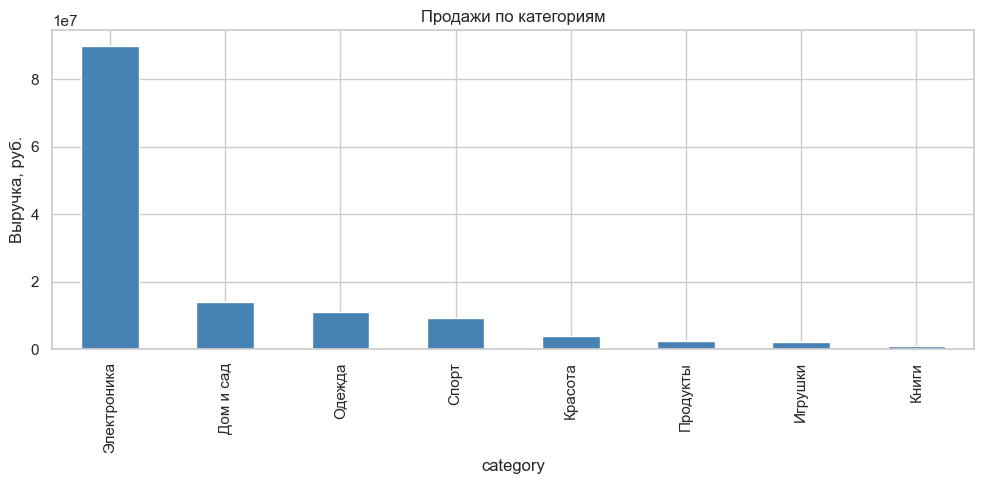

In [105]:
(
    df
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .plot(kind='bar', figsize=(10, 5), title='Продажи по категориям', color='steelblue')
)
plt.ylabel('Выручка, руб.')
plt.tight_layout()
plt.show()

**Разбор:**
- После `.groupby('category')['amount'].sum()` получается Series: индекс — категории, значения — суммы.
- `.plot(kind='bar')` строит столбцы прямо из этого Series: **индекс идёт на ось X, значения — на ось Y**.
- Параметры прямо в `.plot()`: `figsize` (размер), `title` (заголовок), `color` (цвет).
- `plt.tight_layout()` убирает обрезку подписей. `plt.show()` отображает график.

Это черновик: быстро и без церемоний. Для отчёта мы перестроим его в Matplotlib (раздел 3).

### 2.2. Несколько линий из pivot_table

`pivot_table` даёт широкий формат, и `.plot()` рисует каждую колонку отдельной линией.

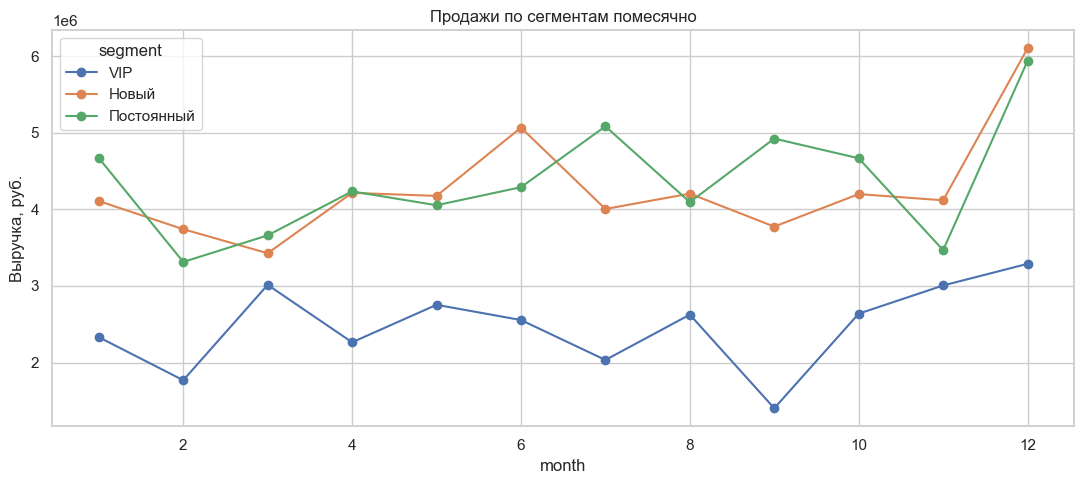

In [107]:
pivot_month = df.pivot_table(index='month', columns='segment',
                             values='amount', aggfunc='sum', fill_value=0)

pivot_month.plot(kind='line', figsize=(11, 5), marker='o',
                 title='Продажи по сегментам помесячно')
plt.ylabel('Выручка, руб.')
plt.tight_layout()
plt.show()

**Разбор:** после `pivot_table` каждый сегмент — отдельная колонка. `.plot(kind='line')` автоматически:
- ставит индекс (`month`) на ось X,
- рисует каждую колонку (`Новый`, `Постоянный`, `VIP`) отдельной линией,
- добавляет легенду с названиями колонок.

`marker='o'` ставит точки на каждом значении.

### 2.3. Stacked bar и нормализованный stacked bar

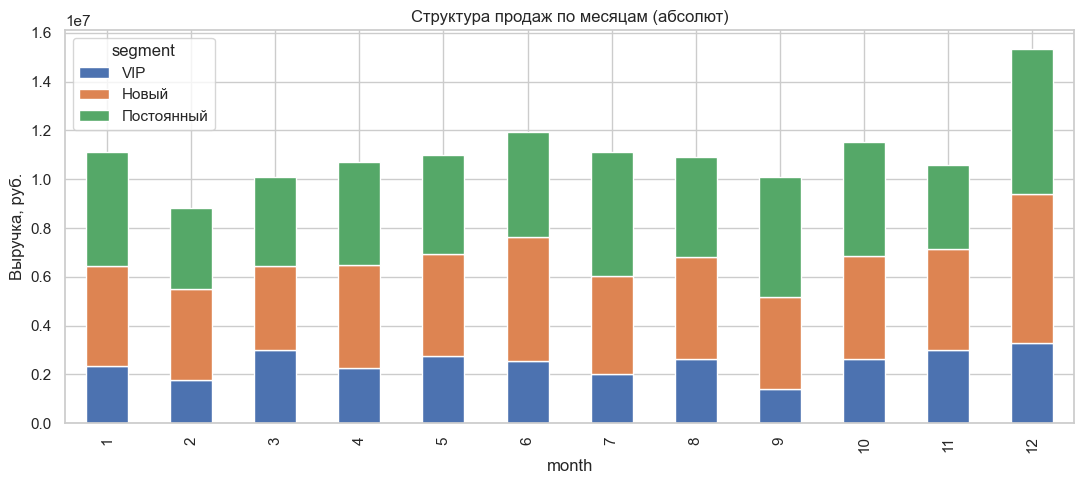

In [113]:
# Абсолютные значения — накопительные столбцы
pivot_month.plot(kind='bar', stacked=True, figsize=(11, 5),
                 title='Структура продаж по месяцам (абсолют)')
plt.ylabel('Выручка, руб.')
plt.tight_layout()
plt.show()

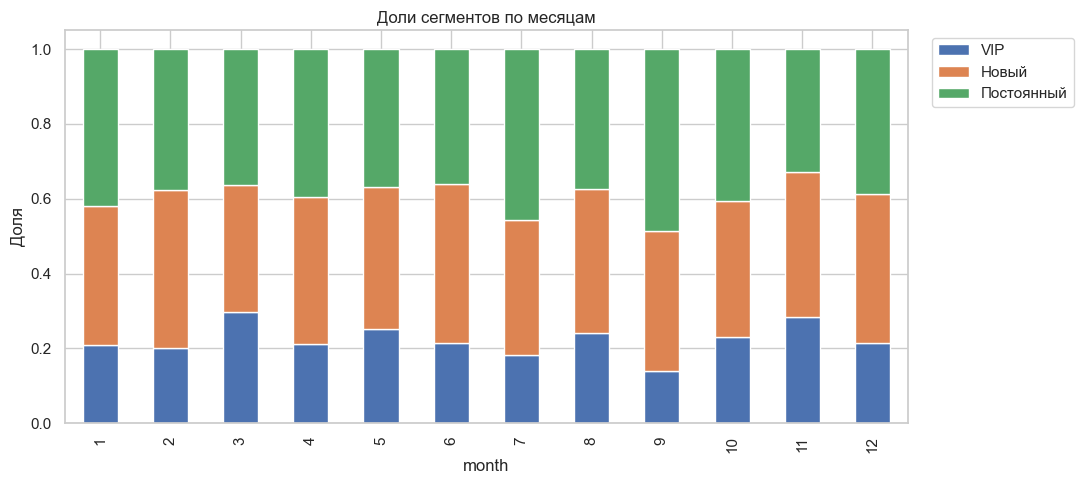

In [73]:
# Доли — нормализуем каждую строку к 1
pivot_pct = pivot_month.div(pivot_month.sum(axis=1), axis=0)

pivot_pct.plot(kind='bar', stacked=True, figsize=(11, 5),
               title='Доли сегментов по месяцам')
plt.ylabel('Доля')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')  # легенду вынесли вправо
plt.tight_layout()
plt.show()

**Разбор нормализации:**
- `pivot_month.sum(axis=1)` — сумма по каждой строке (всего за месяц по всем сегментам).
- `.div(..., axis=0)` — делит каждую строку на её сумму. Получаются доли, сумма которых = 1.
- `bbox_to_anchor=(1.02, 1)` — выносит легенду за пределы графика вправо, чтобы она не перекрывала столбцы.

Абсолютный stacked bar отвечает «сколько», нормализованный — «какая доля».

### 2.4. Получение Axes для доработки

Важный приём: `.plot()` возвращает объект `ax`. Можно начать быстро, а потом доработать средствами Matplotlib.

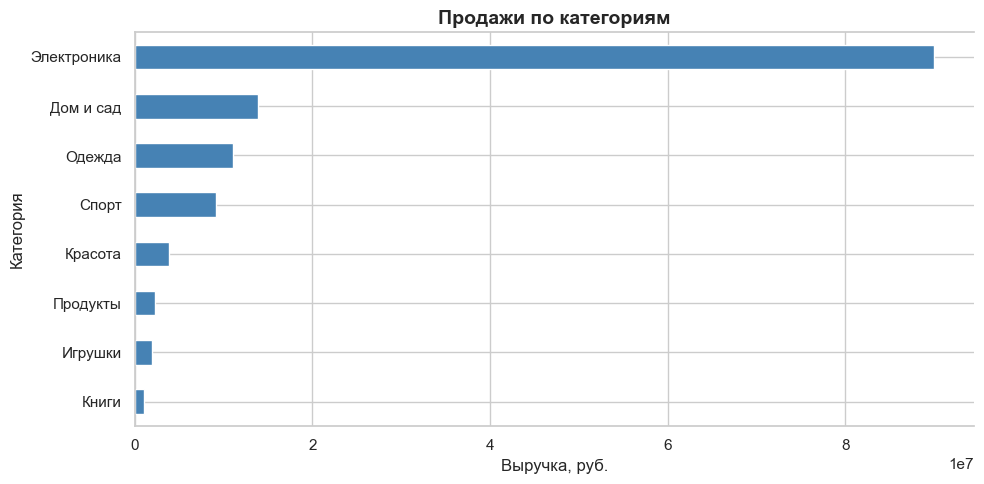

In [116]:
# .plot() возвращает ax — продолжаем настройку через него
ax = (df.groupby('category')['amount'].sum()
        .sort_values()
        .plot(kind='barh', figsize=(10, 5), color='steelblue'))

# Дорабатываем через Matplotlib-методы
ax.set_title('Продажи по категориям', fontsize=14, fontweight='bold')
ax.set_xlabel('Выручка, руб.')
ax.set_ylabel('Категория')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Разбор:** `pandas.plot` и Matplotlib — не разные миры. `.plot()` возвращает тот же `ax`, что и `plt.subplots()`. Поэтому к быстрому графику можно добавить любую настройку Matplotlib: заголовок, подписи, убрать рамки (`spines`). Это мост между черновиком и чистовиком.

---

## 3. Matplotlib — фундамент

Полный контроль над графиком. Основной стиль — **объектный**: `fig, ax = plt.subplots()`.

- `fig` — холст (для общего заголовка и сохранения),
- `ax` — область графика (всё остальное рисуем на нём).

### 3.1. Линейный график с форматированием дат

Самый частый график в аналитике — динамика во времени.

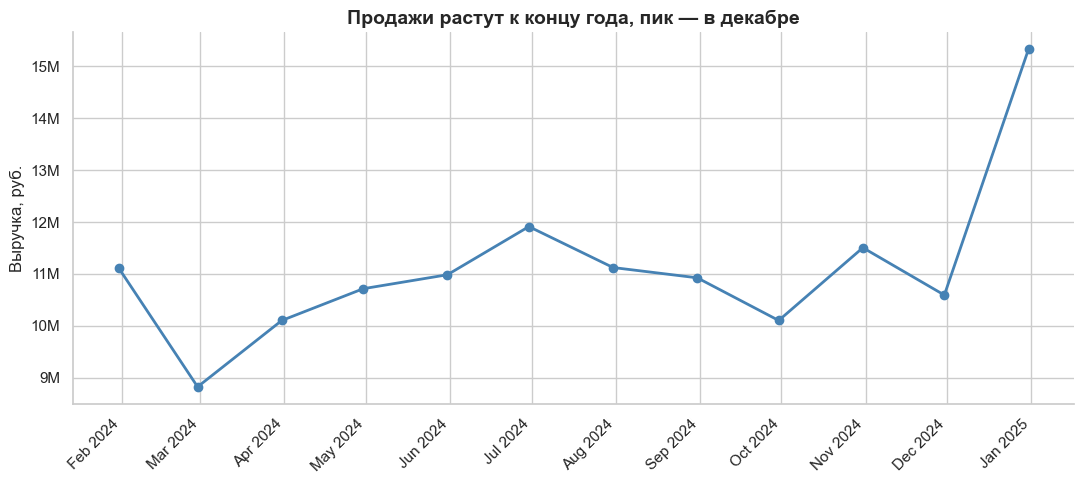

In [75]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

monthly = (df.set_index('date').resample('ME')['amount'].sum().reset_index())

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(monthly['date'], monthly['amount'],
        color='steelblue', linewidth=2, marker='o')

# Форматируем даты на оси X: показывать "янв 2024"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# Форматируем суммы на оси Y: показывать в миллионах
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v/1e6:.0f}M'))

ax.set_title('Продажи растут к концу года, пик — в декабре',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Выручка, руб.')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.autofmt_xdate(rotation=45)  # поворачиваем подписи дат

plt.tight_layout()
plt.show()

**Разбор по блокам:**

*Создание:* `fig, ax = plt.subplots(figsize=(11, 5))` — холст и область графика. `figsize` в дюймах (ширина, высота).

*Линия:* `ax.plot(x, y, color=, linewidth=, marker=)` — рисует линию. `marker='o'` ставит точки.

*Форматирование дат:*
- `mdates.DateFormatter('%b %Y')` — задаёт формат подписи: `%b` сокращённое название месяца, `%Y` год. Другие: `%d` день, `%m` номер месяца.
- `mdates.MonthLocator(interval=1)` — ставит деление на каждый месяц.

*Форматирование чисел:* `FuncFormatter(lambda v, p: f'{v/1e6:.0f}M')` — функция, которая каждое значение оси делит на миллион и добавляет «M». Так `15000000` превращается в `15M`.

*Оформление:* `set_title` с `fontweight='bold'`, `set_ylabel`, убираем верхнюю и правую рамки через `spines`.

*Даты:* `fig.autofmt_xdate(rotation=45)` поворачивает подписи дат, чтобы не налезали.

Заметь заголовок: он формулирует **вывод** («растут к концу года»), а не тему («продажи по месяцам»).

### 3.2. Скользящее среднее — сглаживание шума

Дневные продажи скачут. Скользящее среднее показывает тренд.

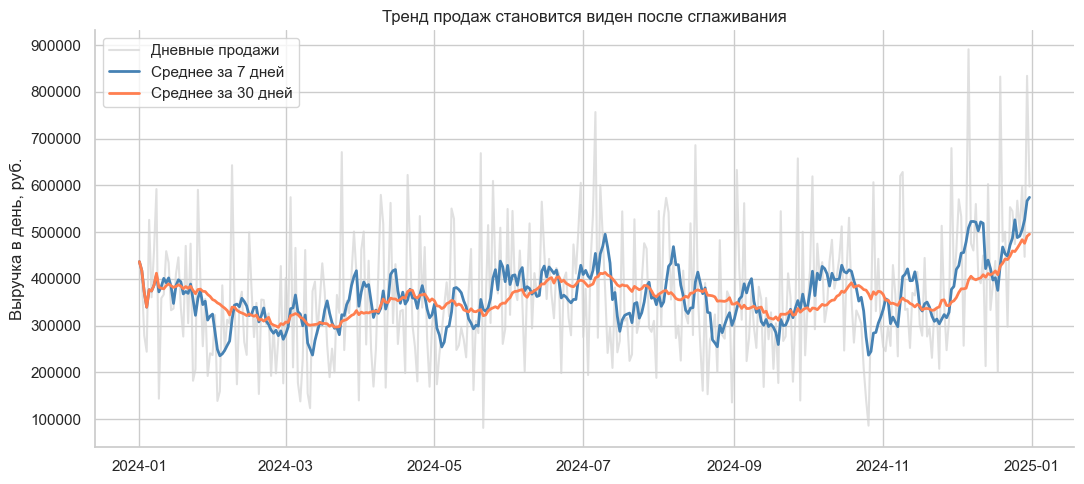

In [76]:
daily = df.set_index('date').resample('D')['amount'].sum().reset_index()
daily['ma7'] = daily['amount'].rolling(7, min_periods=1).mean()    # среднее за 7 дней
daily['ma30'] = daily['amount'].rolling(30, min_periods=1).mean()  # за 30 дней

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(daily['date'], daily['amount'], color='lightgray', alpha=0.7, label='Дневные продажи')
ax.plot(daily['date'], daily['ma7'], color='steelblue', linewidth=2, label='Среднее за 7 дней')
ax.plot(daily['date'], daily['ma30'], color='coral', linewidth=2, label='Среднее за 30 дней')

ax.set_title('Тренд продаж становится виден после сглаживания')
ax.set_ylabel('Выручка в день, руб.')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Разбор:**
- `.rolling(7, min_periods=1).mean()` — скользящее окно из 7 значений, для каждого дня берёт среднее за этот и 6 предыдущих дней.
- `min_periods=1` — в начале ряда (когда ещё нет 7 дней) считает по тому, что есть, вместо `NaN`.
- Приём с цветами: сырые данные — серым полупрозрачным (`lightgray`, `alpha=0.7`), сглаженные линии — яркими. Внимание идёт на тренд, а шум остаётся фоном.
- Чем больше окно (30 vs 7), тем более гладкая линия, но тем сильнее запаздывание.

### 3.3. Grouped bar — сравнение двух периодов

Сравним первое и второе полугодие по категориям.

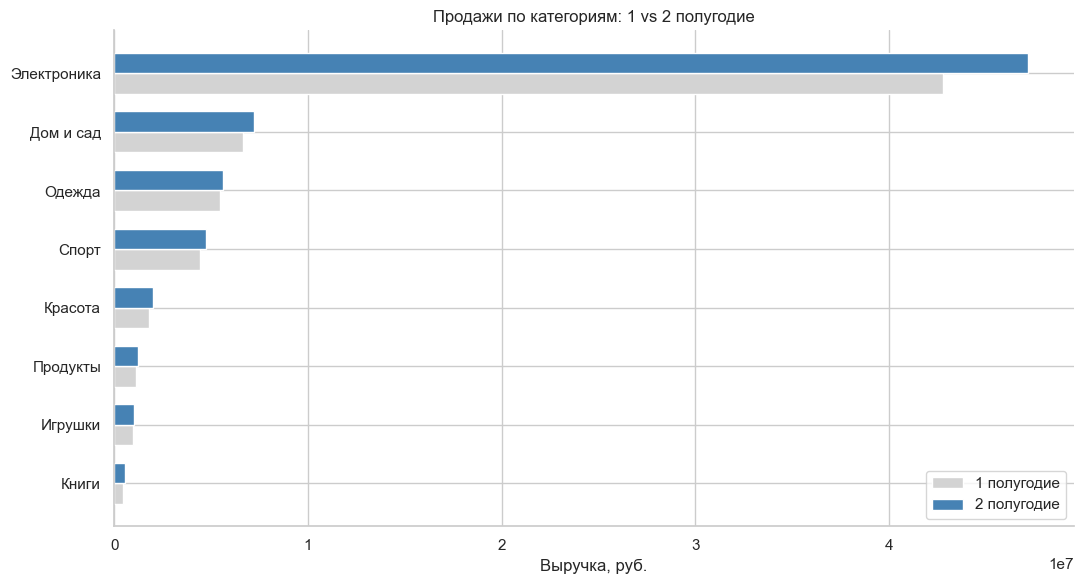

In [118]:
# Готовим данные: добавляем полугодие и разворачиваем в pivot
df['half'] = np.where(df['date'].dt.month <= 6, '1 полугодие', '2 полугодие')
pivot_half = df.pivot_table(index='category', columns='half', values='amount', aggfunc='sum')
pivot_half = pivot_half.sort_values('2 полугодие')

x = np.arange(len(pivot_half.index))  # позиции категорий: 0, 1, 2, ...
width = 0.35                           # ширина одного столбца

fig, ax = plt.subplots(figsize=(11, 6))

# Два набора столбцов со смещением влево и вправо от позиции
ax.barh(x - width/2, pivot_half['1 полугодие'], width, label='1 полугодие', color='lightgray')
ax.barh(x + width/2, pivot_half['2 полугодие'], width, label='2 полугодие', color='steelblue')

ax.set_yticks(x)                       # деления на позициях категорий
ax.set_yticklabels(pivot_half.index)   # подписываем их названиями
ax.set_title('Продажи по категориям: 1 vs 2 полугодие')
ax.set_xlabel('Выручка, руб.')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Разбор механики grouped bar** (единственный нетривиальный момент в столбчатых графиках):
- `x = np.arange(len(categories))` — числовые позиции категорий: 0, 1, 2, …
- `width = 0.35` — ширина столбца. Два столбца + зазор должны помещаться в 1.0.
- `x - width/2` и `x + width/2` — смещаем первый набор влево, второй вправо от позиции, чтобы они стояли рядом, а не друг на друге.
- `set_yticks(x)` + `set_yticklabels(...)` — ставим деления на числовые позиции и подписываем их названиями категорий.

(Здесь использован `barh` — горизонтальный — потому что названия категорий длинные. Для вертикального было бы `bar` и `set_xticks`.)

### 3.4. Гистограмма с линиями среднего и медианы

Распределение сумм заказа. Покажем правый хвост.

/var/folders/ls/d6mbmny12hb59h29c1bx9rsm0000gn/T/ipykernel_8117/2007152181.py:17: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/artempolyakov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


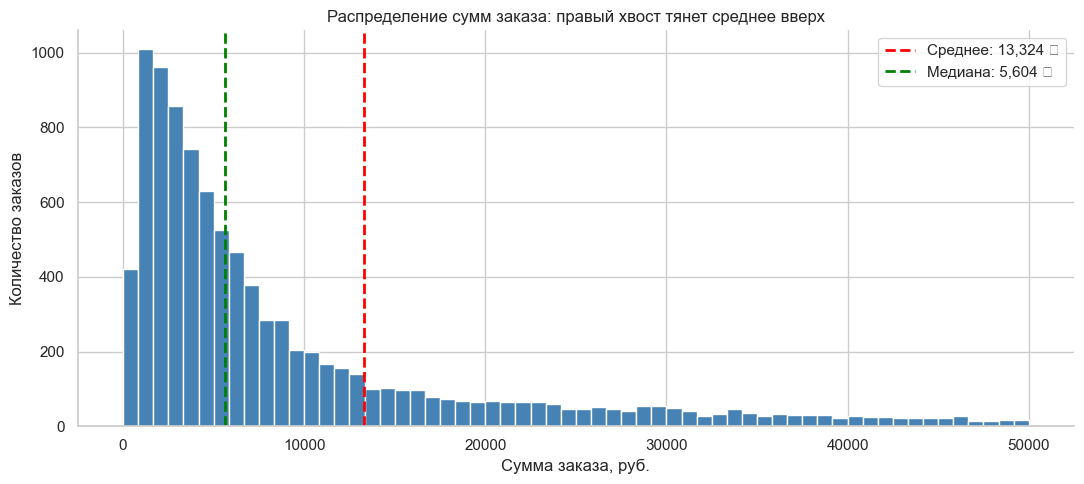

In [78]:
fig, ax = plt.subplots(figsize=(11, 5))

# Ограничим ось X 50 тысячами, чтобы хвост не сжимал основную массу данных
ax.hist(df['amount'], bins=60, range=(0, 50000), color='steelblue', edgecolor='white')

mean_val = df['amount'].mean()
median_val = df['amount'].median()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:,.0f} ₽')
ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:,.0f} ₽')

ax.set_title('Распределение сумм заказа: правый хвост тянет среднее вверх')
ax.set_xlabel('Сумма заказа, руб.')
ax.set_ylabel('Количество заказов')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Разбор:**
- `ax.hist(data, bins=60, range=(0, 50000))` — гистограмма с 60 корзинами, ограниченная диапазоном 0–50000 (иначе редкие заказы на 200к растянули бы ось и сжали основную массу в один столбик).
- `edgecolor='white'` — белые границы столбцов, чтобы они визуально разделялись.
- `ax.axvline(x, ...)` — вертикальная линия. Рисуем среднее (красным) и медиану (зелёным).
- В `label` через f-строку вставляем само значение: `f'Среднее: {mean_val:,.0f} ₽'`. Здесь `:,.0f` — формат с разделителем тысяч и без дробной части.

**Вывод графика:** среднее заметно правее медианы. Это значит — распределение асимметрично, и «средний чек» вводит в заблуждение: половина заказов меньше медианы.

### 3.5. Несколько графиков на одном холсте (subplots)

Дашборд из 4 графиков в сетке 2×2.

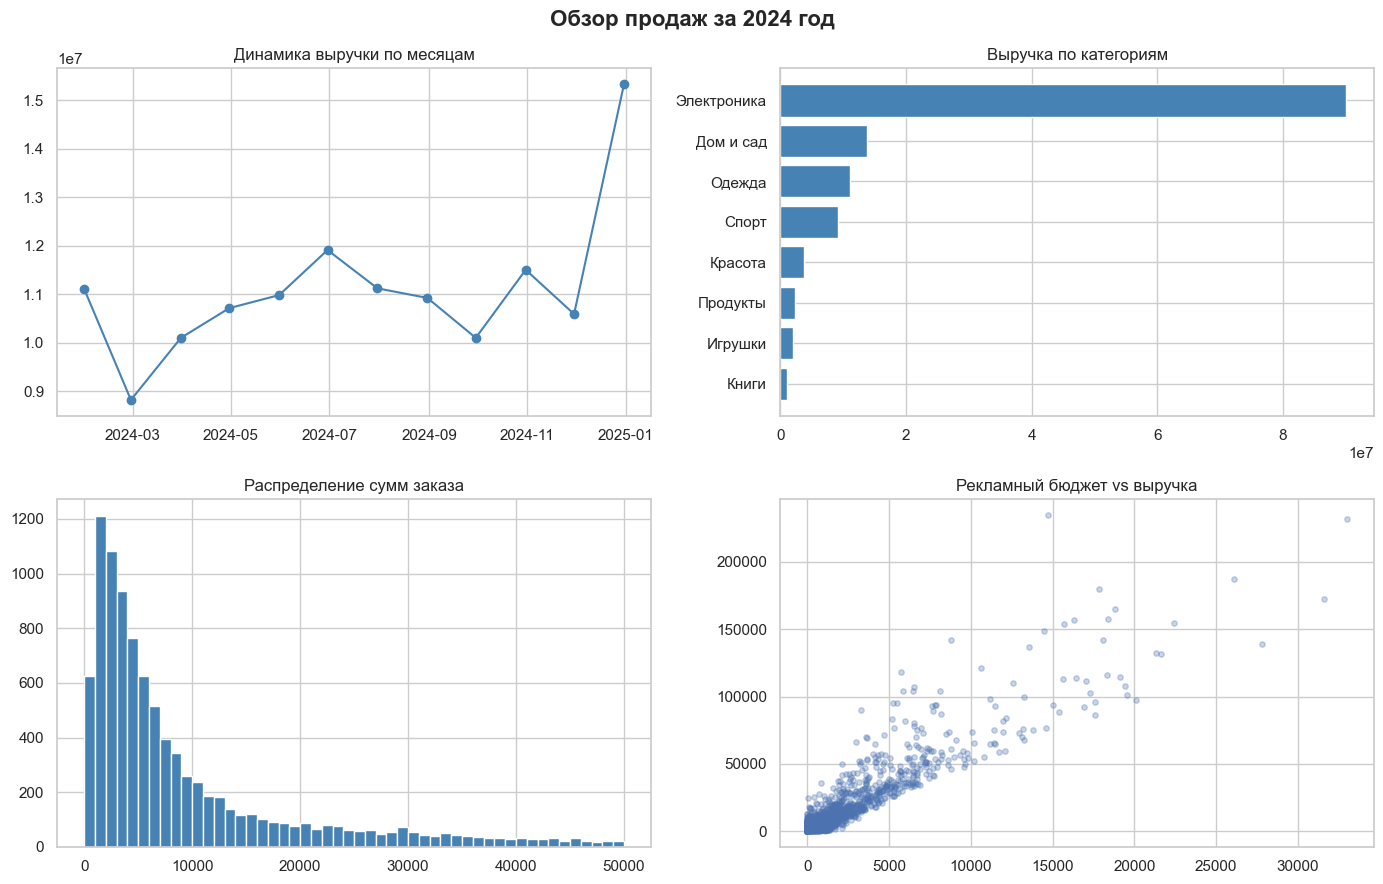

In [79]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9))

# [0, 0] — динамика по месяцам
monthly = df.set_index('date').resample('ME')['amount'].sum()
axes[0, 0].plot(monthly.index, monthly.values, marker='o', color='steelblue')
axes[0, 0].set_title('Динамика выручки по месяцам')

# [0, 1] — продажи по категориям
cat = df.groupby('category')['amount'].sum().sort_values()
axes[0, 1].barh(cat.index, cat.values, color='steelblue')
axes[0, 1].set_title('Выручка по категориям')

# [1, 0] — распределение сумм
axes[1, 0].hist(df['amount'], bins=50, range=(0, 50000), color='steelblue', edgecolor='white')
axes[1, 0].set_title('Распределение сумм заказа')

# [1, 1] — связь бюджета и продаж
sample = df.dropna(subset=['ad_budget']).sample(2000, random_state=1)
axes[1, 1].scatter(sample['ad_budget'], sample['amount'], alpha=0.3, s=15)
axes[1, 1].set_title('Рекламный бюджет vs выручка')

fig.suptitle('Обзор продаж за 2024 год', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Разбор:**
- `plt.subplots(nrows=2, ncols=2)` создаёт сетку 2×2. `axes` — двумерный массив областей.
- Обращаемся по индексам `[строка, колонка]`: `axes[0, 0]` — верхняя левая, `axes[1, 1]` — нижняя правая.
- К каждой области применяем свои методы: `.plot()`, `.barh()`, `.hist()`, `.scatter()`.
- `fig.suptitle(...)` — общий заголовок над всеми графиками (метод у `fig`, не у `ax`).
- `plt.tight_layout()` расставляет графики так, чтобы они не налезали друг на друга.

> Если бы строка была одна (`nrows=1`), `axes` стал бы одномерным, и обращение было бы `axes[0]`, `axes[1]`.

---

## 4. Seaborn — статистическая визуализация

Построен поверх Matplotlib. Короче синтаксис, работает с DataFrame напрямую, сам считает статистику.

In [80]:
!pip install seaborn

zsh:1: command not found: pip


In [81]:
import seaborn as sns
sns.set_theme(style='whitegrid')  # единый аккуратный стиль для всех графиков ниже

### 4.1. Главная ловушка: barplot считает СРЕДНЕЕ

Это самый важный момент в Seaborn для новичка.

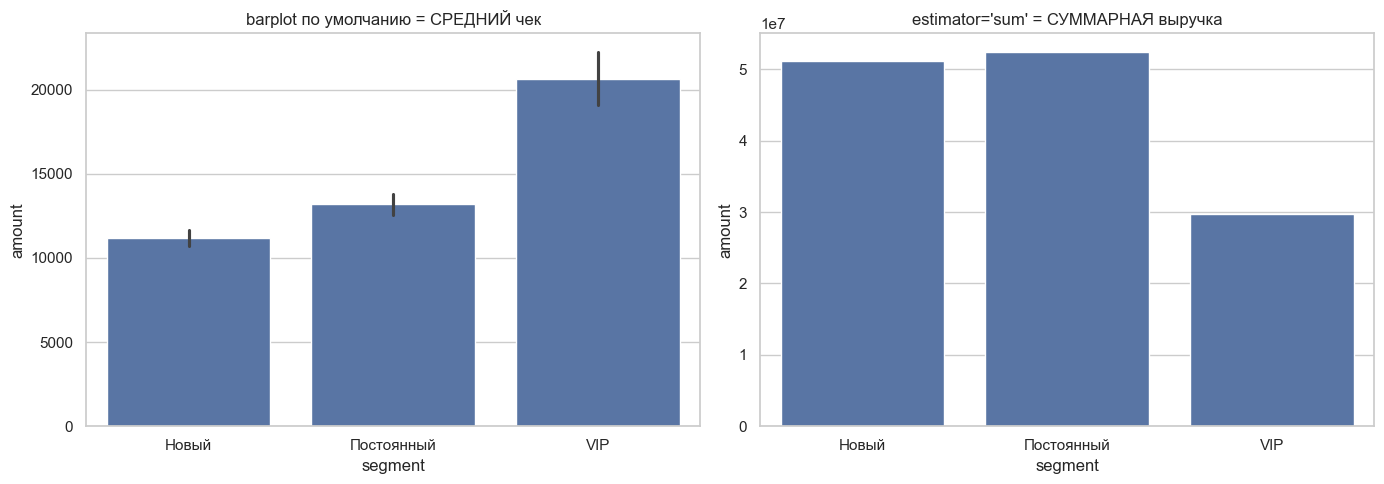

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# СЛЕВА: barplot по умолчанию показывает СРЕДНЕЕ (+ доверительный интервал)
sns.barplot(data=df, x='segment', y='amount', ax=axes[0])
axes[0].set_title('barplot по умолчанию = СРЕДНИЙ чек')

# СПРАВА: то же, но с estimator='sum' — теперь СУММА
sns.barplot(data=df, x='segment', y='amount', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title("estimator='sum' = СУММАРНАЯ выручка")

plt.tight_layout()
plt.show()

**Разбор — почему это важно:**
- Слева высота столбца — это **среднее** значение `amount` по сегменту, а тонкие чёрточки сверху — доверительный интервал. Если ты ждал сумму, результат удивит.
- Справа `estimator='sum'` переключает на сумму, а `errorbar=None` убирает доверительный интервал.
- Картина **противоположная**: по среднему чеку лидирует VIP, а по суммарной выручке — самый массовый сегмент.

> **Правило безопасности:** если не уверен, что показывает `barplot` — агрегируй данные в pandas заранее (как в разделе 1.2) и подавай готовую таблицу. Тогда никакой скрытой агрегации не будет.

### 4.2. Boxplot и violinplot — сравнение распределений по группам

В Matplotlib это требует подготовки списков. В Seaborn — одна строка.

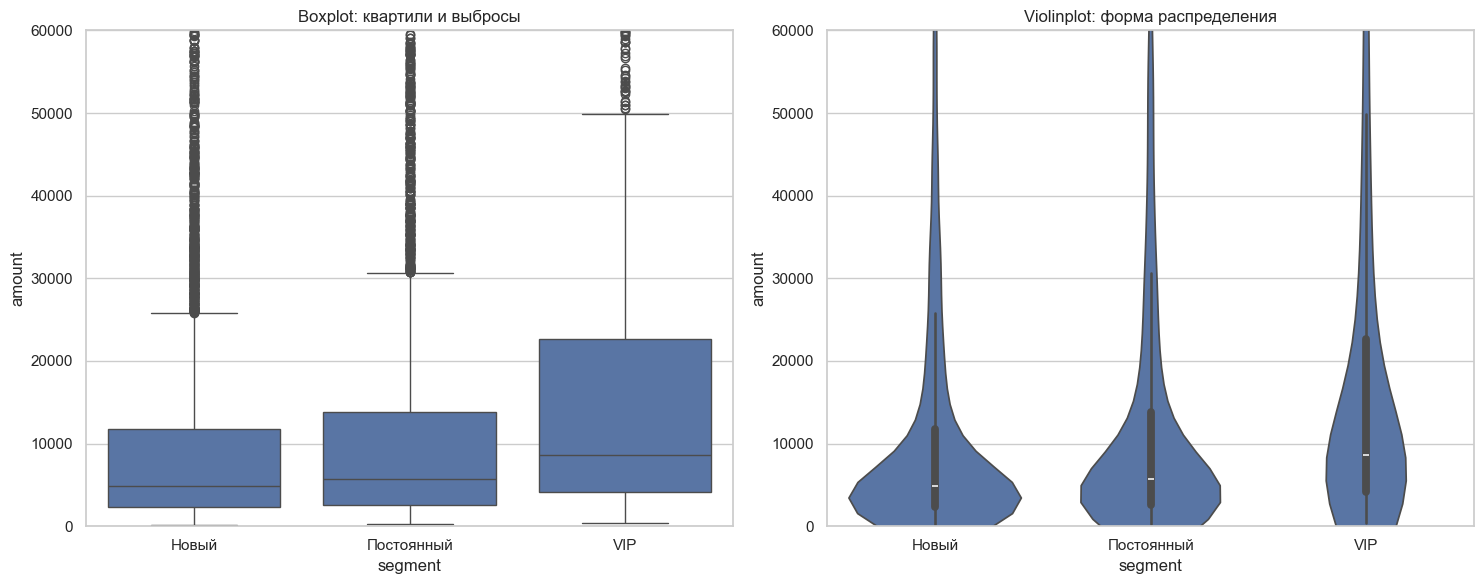

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot — компактно: медиана, квартили, выбросы
sns.boxplot(data=df, x='segment', y='amount', ax=axes[0])
axes[0].set_title('Boxplot: квартили и выбросы')
axes[0].set_ylim(0, 60000)  # обрежем хвост для читаемости

# Violinplot — добавляет форму распределения (ширина = плотность)
sns.violinplot(data=df, x='segment', y='amount', ax=axes[1])
axes[1].set_title('Violinplot: форма распределения')
axes[1].set_ylim(0, 60000)

plt.tight_layout()
plt.show()

**Разбор:**
- `sns.boxplot(data=df, x='segment', y='amount')` — для каждого значения `x` (сегмента) строит «ящик»: линия = медиана, границы ящика = квартили Q1 и Q3, усы = размах, точки за усами = выбросы.
- `sns.violinplot(...)` — то же плюс форма: чем шире «скрипка» на каком-то уровне, тем больше там наблюдений.
- `set_ylim(0, 60000)` обрезает редкие огромные значения, иначе ящики сожмутся в полоски внизу.

Boxplot компактнее и читается быстрее. Violinplot полезен, когда важна форма (например, два пика).

### 4.3. Сравнение распределений через hue

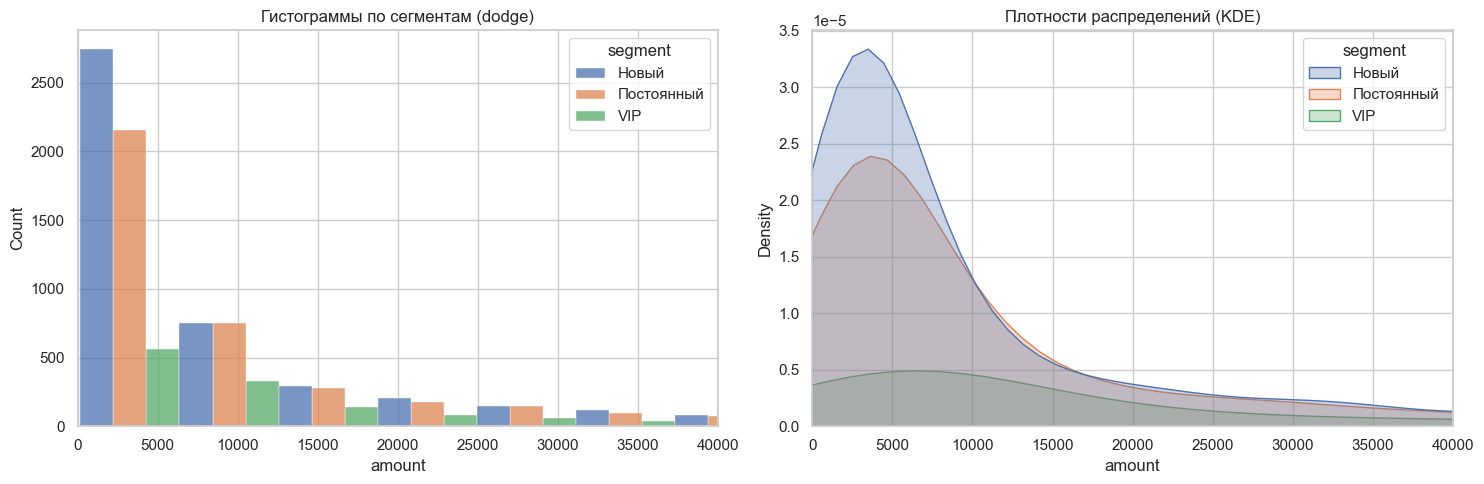

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограммы по сегментам, столбцы рядом (dodge)
sns.histplot(data=df, x='amount', hue='segment', bins=40, multiple='dodge',
             ax=axes[0])
axes[0].set_xlim(0, 40000)
axes[0].set_title('Гистограммы по сегментам (dodge)')

# KDE — сглаженные плотности, наложенные друг на друга
sns.kdeplot(data=df, x='amount', hue='segment', fill=True, alpha=0.3, ax=axes[1])
axes[1].set_xlim(0, 40000)
axes[1].set_title('Плотности распределений (KDE)')

plt.tight_layout()
plt.show()

**Разбор:**
- `hue='segment'` — разбивает данные по сегментам, каждый своим цветом. Работает почти во всех функциях Seaborn.
- `multiple='dodge'` — ставит столбцы групп **рядом**. Альтернативы: `'stack'` (друг на друге), `'layer'` (наложение с прозрачностью).
- `sns.kdeplot(..., fill=True, alpha=0.3)` — сглаженные кривые плотности с полупрозрачной заливкой. Хорошо видно, что VIP-распределение сдвинуто вправо (более дорогие заказы).

### 4.4. Heatmap — корреляции и сводные таблицы

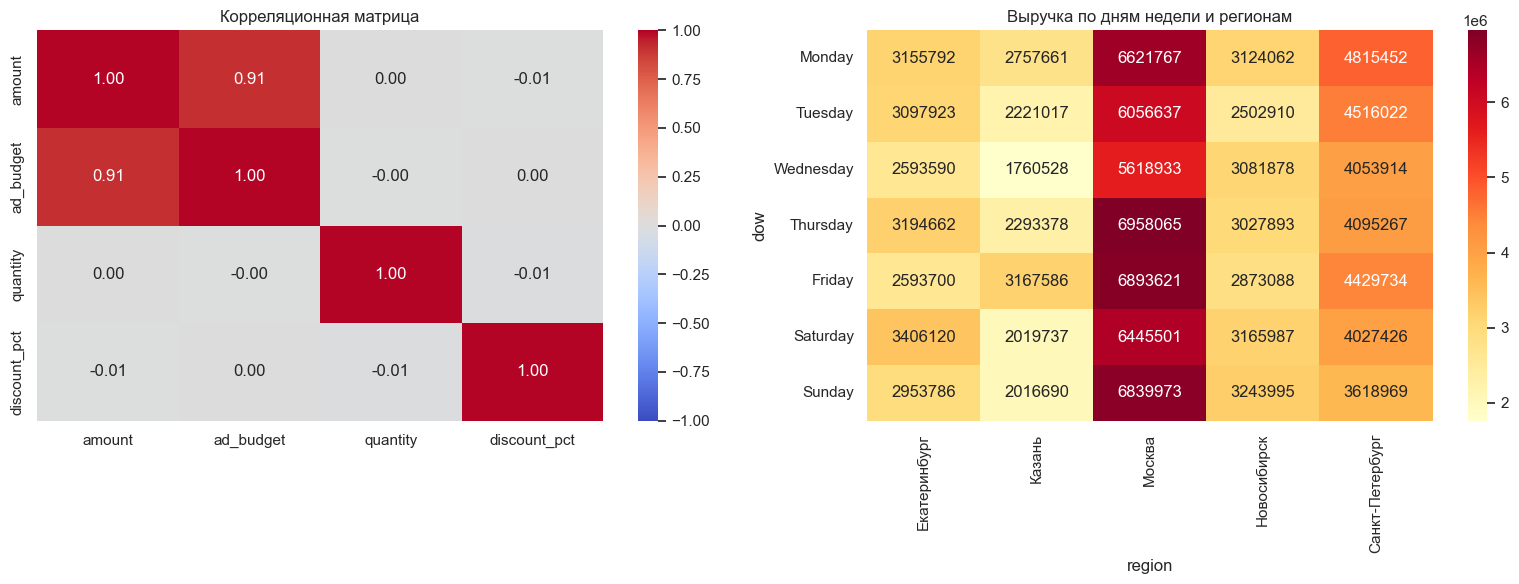

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# СЛЕВА: матрица корреляций
corr = df[['amount', 'ad_budget', 'quantity', 'discount_pct']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Корреляционная матрица')

# СПРАВА: сводная таблица выручки по дням недели и регионам
df['dow'] = df['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_dow = df.pivot_table(index='dow', columns='region', values='amount', aggfunc='sum').reindex(dow_order)
sns.heatmap(pivot_dow, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Выручка по дням недели и регионам')

plt.tight_layout()
plt.show()

**Разбор двух типов heatmap:**

*Корреляции (слева):*
- `df[[...]].corr()` считает попарные корреляции числовых колонок. Значения от −1 до +1.
- `annot=True, fmt='.2f'` — пишет числа в ячейках с 2 знаками.
- `cmap='coolwarm', center=0` — **дивергентная** палитра с центром в нуле: отрицательная корреляция синяя, положительная красная, около нуля белая.
- `vmin=-1, vmax=1` — фиксируем шкалу на диапазоне корреляции.
- Видно сильную связь `amount`–`ad_budget` (бюджет мы и привязывали к сумме).

*Сводная таблица (справа):*
- `cmap='YlOrRd'` — **последовательная** палитра (светлый → тёмный) для величин от 0 до максимума.
- `.reindex(dow_order)` — упорядочивает дни недели по-человечески (иначе были бы по алфавиту).

> Правило: корреляции и отклонения → дивергентная палитра + `center=0`. Объёмы и количества → последовательная палитра.

### 4.5. Scatter с линией регрессии

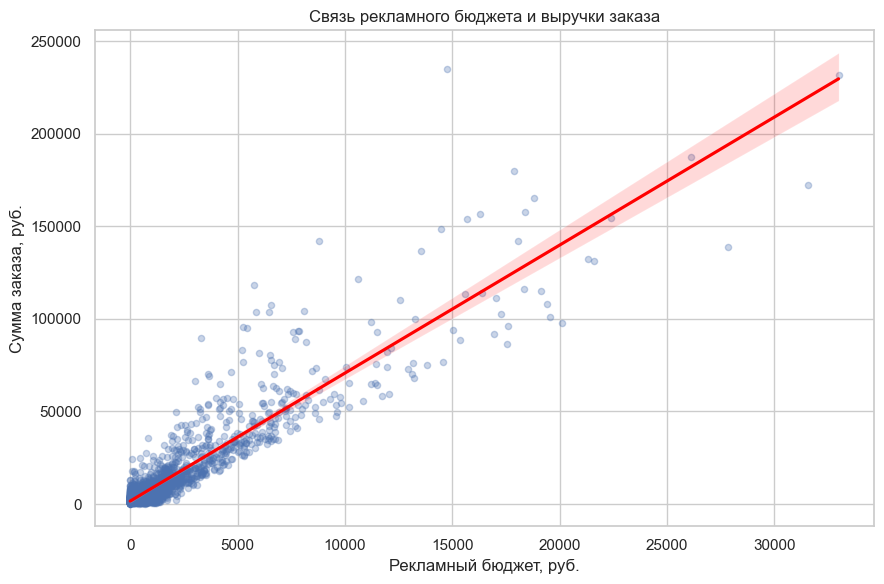

In [86]:
# Берём подвыборку: на 10к точек scatter превращается в кашу
sample = df.dropna(subset=['ad_budget']).sample(2000, random_state=1)

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=sample, x='ad_budget', y='amount',
            scatter_kws={'alpha': 0.3, 's': 20},  # настройки точек
            line_kws={'color': 'red'},             # настройки линии
            ax=ax)
ax.set_title('Связь рекламного бюджета и выручки заказа')
ax.set_xlabel('Рекламный бюджет, руб.')
ax.set_ylabel('Сумма заказа, руб.')
plt.tight_layout()
plt.show()

**Разбор:**
- `.sample(2000, random_state=1)` — случайные 2000 строк. На всех 10к точки слиплись бы. `random_state` фиксирует выборку.
- `sns.regplot` рисует точки **и** линию линейной регрессии с доверительной полосой.
- `scatter_kws` — словарь настроек для точек (`alpha` прозрачность, `s` размер).
- `line_kws` — настройки линии регрессии.
- Восходящая линия подтверждает: чем больше бюджет, тем выше сумма заказа.

> Важно: связь на графике — это **корреляция**, а не доказательство, что бюджет *вызывает* рост продаж.

### 4.6. FacetGrid — малые мультипликаторы (отдельный график на категорию)

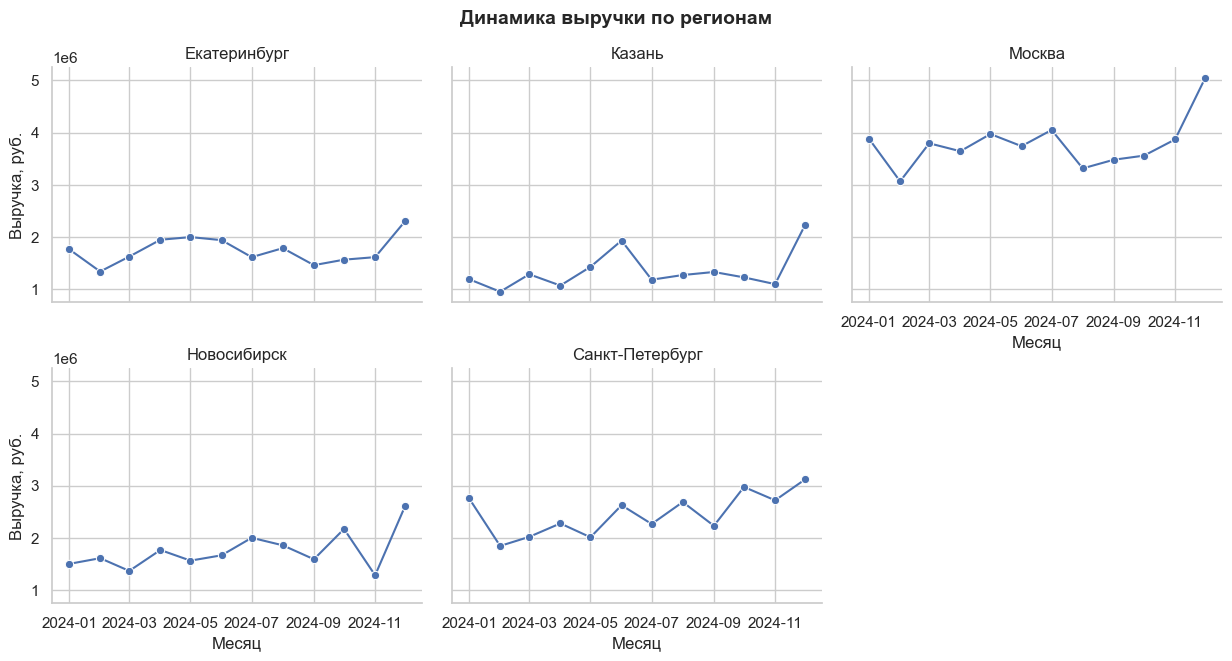

In [87]:
# Динамика по месяцам — отдельный график на каждый регион
monthly_region = (
    df.assign(m=df['date'].dt.to_period('M').dt.to_timestamp())
      .groupby(['m', 'region'], as_index=False)['amount'].sum()
)

g = sns.relplot(
    data=monthly_region,
    x='m', y='amount',
    col='region',       # отдельный подграфик на каждый регион
    col_wrap=3,         # по 3 в ряд, дальше перенос
    kind='line',
    height=3.2, aspect=1.3,
    marker='o'
)
g.set_titles('{col_name}')                       # заголовок подграфика = название региона
g.set_axis_labels('Месяц', 'Выручка, руб.')
g.fig.suptitle('Динамика выручки по регионам', y=1.03, fontsize=14, fontweight='bold')
plt.show()

**Разбор:**
- `sns.relplot` — это **figure-level** функция: она создаёт целую фигуру с сеткой подграфиков. У неё нет `ax=`, размер задаётся через `height` и `aspect` (а не `figsize`).
- `col='region'` — делает отдельный подграфик для каждого региона.
- `col_wrap=3` — переносит на новую строку после 3 графиков (иначе все вытянулись бы в один ряд).
- `kind='line'` — тип графика внутри (для relplot бывает `'scatter'` и `'line'`).
- Объект называется `g` (это FacetGrid). Заголовок ставим через `g.fig.suptitle`, подписи — через методы `g`.

Малые мультипликаторы — лучший способ сравнить одну и ту же динамику между сегментами.

---

## 5. Plotly — интерактивная визуализация

Графики с hover-подсказками, зумом, кликабельной легендой. Наведи мышь на элемент — увидишь детали. Результат можно сохранить в HTML и отправить коллеге.

In [88]:
!pip install seaborn plotly

zsh:1: command not found: pip


In [89]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### 5.1. Plotly Express — интерактивный линейный график

`px` работает с DataFrame и напоминает Seaborn. Попробуй навести мышь на линии и кликнуть по легенде.

In [90]:
!pip install nbformat

zsh:1: command not found: pip


In [91]:
import sys
!{sys.executable} -m pip install nbformat


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [92]:
monthly_seg = (
    df.assign(m=df['date'].dt.to_period('M').dt.to_timestamp())
      .groupby(['m', 'segment'], as_index=False)['amount'].sum()
)

fig = px.line(
    monthly_seg,
    x='m', y='amount',
    color='segment',                       # отдельная линия и цвет на сегмент
    markers=True,
    title='Динамика выручки по сегментам (интерактив)',
    labels={'m': 'Месяц', 'amount': 'Выручка, руб.', 'segment': 'Сегмент'}
)
fig.update_layout(hovermode='x unified')   # единая подсказка по всем линиям сразу
fig.show()

**Разбор:**
- `px.line(df, x=, y=, color=)` — линейный график. `color='segment'` создаёт по линии на сегмент, как `hue` в Seaborn.
- `labels={...}` — словарь человекочитаемых подписей для осей и легенды (вместо имён колонок).
- `markers=True` — точки на линиях.
- `fig.update_layout(hovermode='x unified')` — при наведении показывает значения **всех** линий для данного месяца в одной подсказке. Очень удобно для сравнения.
- `fig.show()` отображает интерактивный график прямо в ноутбуке.

Попробуй: наведи мышь на точку, кликни на сегмент в легенде (он скроется), выдели область мышью (зум).

### 5.2. Scatter с hover-деталями

Главная польза интерактива — навёл на точку и увидел, что это за заказ.

In [93]:
sample = df.dropna(subset=['ad_budget']).sample(1500, random_state=1)

fig = px.scatter(
    sample,
    x='ad_budget', y='amount',
    color='segment',
    size='quantity',                          # размер точки = количество товаров
    hover_data={                              # что показывать при наведении
        'category': True,
        'region': True,
        'ad_budget': ':,.0f',                 # формат: разделитель тысяч
        'amount': ':,.0f',
    },
    title='Бюджет vs выручка (наведи на точку)',
    labels={'ad_budget': 'Бюджет, руб.', 'amount': 'Выручка, руб.'}
)
fig.show()

**Разбор:**
- `size='quantity'` — диаметр точки кодирует количество товаров в заказе (третье измерение).
- `hover_data` — словарь: какие поля показывать в подсказке и как форматировать. `True` — показать как есть, `':,.0f'` — формат с разделителем тысяч без дробей.
- Формат чисел в Plotly использует синтаксис d3: `:,.0f` (тысячи), `:.1%` (проценты), `$,.0f` (валюта). Он отличается от Python — это частый источник путаницы.

Наведи на любую точку — увидишь категорию, регион, бюджет и сумму конкретного заказа.

### 5.3. Treemap — иерархическая структура

In [94]:
fig = px.treemap(
    df,
    path=['region', 'category'],   # иерархия: регион -> категория внутри него
    values='amount',
    title='Структура выручки: регионы и категории'
)
fig.update_traces(textinfo='label+percent parent')  # показывать долю внутри региона
fig.show()

**Разбор:**
- `px.treemap(df, path=[...], values=)` — прямоугольники, площадь = сумма `amount`.
- `path=['region', 'category']` задаёт иерархию: верхний уровень — регионы, внутри каждого — его категории. Клик по региону «проваливается» внутрь.
- `textinfo='label+percent parent'` — на плитке показывается название и доля внутри родителя.

Treemap — хорошая замена pie chart, когда категорий много: площади сравнивать легче, чем углы.

### 5.4. Graph Objects — комбинированный график со вторичной осью

Когда нужны два типа графика вместе или две оси Y — переходим на `go`.

In [95]:
monthly_combo = (
    df.assign(m=df['date'].dt.to_period('M').dt.to_timestamp())
      .groupby('m', as_index=False)
      .agg(revenue=('amount', 'sum'), orders=('order_id', 'count'))
)

# Создаём фигуру с двумя осями Y
fig = make_subplots(specs=[[{'secondary_y': True}]])

# Столбцы — выручка (левая ось)
fig.add_trace(
    go.Bar(x=monthly_combo['m'], y=monthly_combo['revenue'], name='Выручка', marker_color='steelblue'),
    secondary_y=False
)
# Линия — количество заказов (правая ось)
fig.add_trace(
    go.Scatter(x=monthly_combo['m'], y=monthly_combo['orders'], name='Заказы',
               mode='lines+markers', marker_color='coral'),
    secondary_y=True
)

fig.update_layout(title='Выручка и количество заказов по месяцам', template='plotly_white')
fig.update_yaxes(title_text='Выручка, руб.', secondary_y=False)
fig.update_yaxes(title_text='Количество заказов', secondary_y=True)
fig.show()

**Разбор:**
- `make_subplots(specs=[[{'secondary_y': True}]])` — создаёт фигуру с возможностью второй оси Y.
- График строится из **traces** (серий). `fig.add_trace(...)` добавляет каждую.
- `go.Bar(...)` — столбцы, `go.Scatter(..., mode='lines+markers')` — линия с точками.
- `secondary_y=False/True` — указывает, к какой оси привязать серию: выручка к левой, заказы к правой.
- `template='plotly_white'` — чистая светлая тема.

> Вторичная ось удобна для метрик в разных единицах (рубли и штуки), но используй её осторожно: разными масштабами можно создать ложное впечатление связи.

### 5.5. Экспорт в HTML

Главное преимущество Plotly — сохранить интерактивный график в файл, который открывается в браузере без Python.

In [96]:
# Сохраняем последний график в самодостаточный HTML
fig.write_html('chart_interactive.html')
print('Сохранено в chart_interactive.html — открывается двойным кликом в браузере')

# Чтобы файл был легче (Plotly грузится из интернета, а не встраивается):
# fig.write_html('chart_interactive.html', include_plotlyjs='cdn')

Сохранено в chart_interactive.html — открывается двойным кликом в браузере


**Разбор:**
- `fig.write_html('file.html')` — сохраняет график со всей интерактивностью в один HTML-файл. Его можно отправить коллеге, и он откроет двойным кликом.
- `include_plotlyjs='cdn'` — делает файл лёгким: библиотека Plotly подгружается из интернета, а не встраивается в файл (минус — нужен интернет при открытии).
- Для статичной картинки (PNG/SVG/PDF) используется `fig.write_image(...)`, но он требует пакет `kaleido`.

---

## 6. Выбор графика под задачу

Несколько типовых аналитических задач с готовым кодом. Принцип: **сначала вопрос — потом график**.

### 6.1. «Выполнили ли менеджеры план?» → bar с линией плана

/var/folders/ls/d6mbmny12hb59h29c1bx9rsm0000gn/T/ipykernel_8117/464750785.py:16: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/artempolyakov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


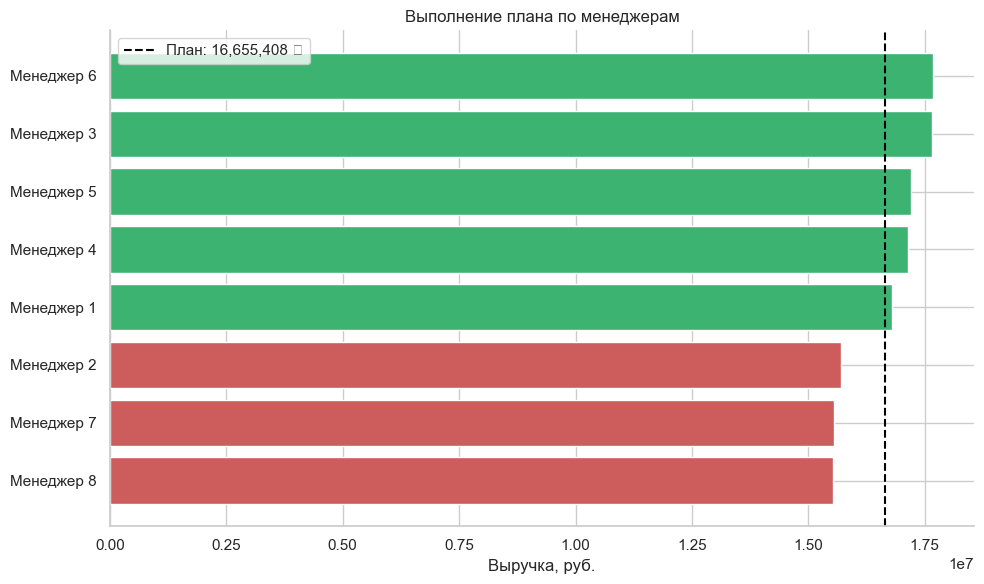

In [97]:
mgr = df.groupby('manager', as_index=False)['amount'].sum().sort_values('amount')
plan = mgr['amount'].mean()  # за план примем средний результат

# Цвет столбца зависит от выполнения плана
colors = ['mediumseagreen' if v >= plan else 'indianred' for v in mgr['amount']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mgr['manager'], mgr['amount'], color=colors)
ax.axvline(plan, color='black', linestyle='--', label=f'План: {plan:,.0f} ₽')

ax.set_title('Выполнение плана по менеджерам')
ax.set_xlabel('Выручка, руб.')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Разбор приёма с цветом:**
- `['mediumseagreen' if v >= plan else 'indianred' for v in mgr['amount']]` — list comprehension: для каждого значения возвращает зелёный, если план выполнен, иначе красный.
- Этот список передаётся в `color=` — каждый столбец получает свой цвет.
- `ax.axvline(plan, ...)` — вертикальная линия плана. Сразу видно, кто выше, кто ниже.

Один взгляд — и понятно, кто справился: зелёные превысили план, красные — нет.

### 6.2. «Что изменилось между полугодиями?» → slope chart

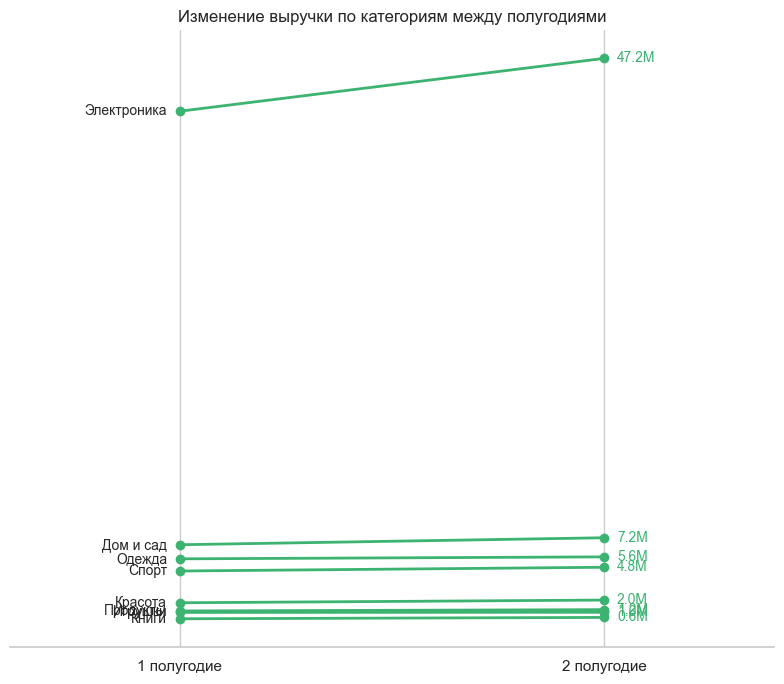

In [98]:
slope_data = (
    df.pivot_table(index='category', columns='half', values='amount', aggfunc='sum')
)

fig, ax = plt.subplots(figsize=(8, 7))
for category, row in slope_data.iterrows():
    h1, h2 = row['1 полугодие'], row['2 полугодие']
    color = 'mediumseagreen' if h2 >= h1 else 'indianred'
    ax.plot([0, 1], [h1, h2], marker='o', color=color, linewidth=2)
    ax.text(-0.03, h1, category, ha='right', va='center', fontsize=10)
    ax.text(1.03, h2, f'{h2/1e6:.1f}M', ha='left', va='center', fontsize=10, color=color)

ax.set_xticks([0, 1])
ax.set_xticklabels(['1 полугодие', '2 полугодие'])
ax.set_title('Изменение выручки по категориям между полугодиями')
ax.set_xlim(-0.4, 1.4)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

**Разбор:**
- Цикл `for category, row in slope_data.iterrows()` идёт по строкам сводной таблицы (по категориям).
- `ax.plot([0, 1], [h1, h2])` — линия из двух точек: слева значение 1-го полугодия, справа 2-го. **Наклон** линии показывает рост или падение.
- Цвет по направлению: зелёный — рост, красный — падение.
- `ax.text(...)` слева подписывает категорию, справа — значение.
- Убираем оси Y и лишние рамки — на slope chart важен только наклон, не точные значения по оси.

Slope chart мгновенно отвечает на вопрос «что выросло, а что упало».

### 6.3. «Сколько % заказов меньше N?» → ECDF

/var/folders/ls/d6mbmny12hb59h29c1bx9rsm0000gn/T/ipykernel_8117/743289332.py:15: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/artempolyakov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


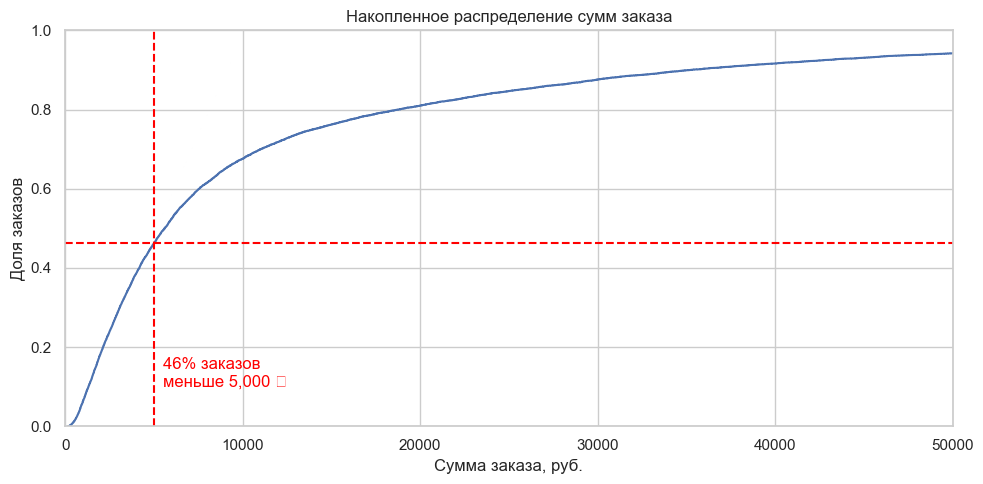

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.ecdfplot(data=df, x='amount', ax=ax)

# Отметим: какая доля заказов меньше 5000 руб.
threshold = 5000
share = (df['amount'] < threshold).mean()
ax.axvline(threshold, color='red', linestyle='--')
ax.axhline(share, color='red', linestyle='--')
ax.text(threshold * 1.1, 0.1, f'{share:.0%} заказов\nменьше {threshold:,} ₽', color='red')

ax.set_title('Накопленное распределение сумм заказа')
ax.set_xlabel('Сумма заказа, руб.')
ax.set_ylabel('Доля заказов')
ax.set_xlim(0, 50000)
plt.tight_layout()
plt.show()

**Разбор:**
- `sns.ecdfplot` строит накопленную долю: для каждого значения по X показывает, какая доля наблюдений **меньше или равна** ему.
- `(df['amount'] < 5000).mean()` — доля заказов меньше 5000. Трюк: сравнение даёт True/False, а `.mean()` от булевых значений = доля True.
- Пунктирные линии и подпись показывают, как читать график: проводим от 5000 вверх до кривой, затем влево — получаем долю.
- `:.0%` форматирует долю как проценты без дробей (0.62 → 62%).

ECDF не зависит от выбора `bins` (в отличие от гистограммы) и прямо отвечает на вопросы «какая доля меньше/больше N».

---

## 7. Мини-проект: отчёт по продажам

Соберём связный набор графиков, как для реального отчёта. Каждый отвечает на конкретный вопрос и сопровождается выводом.

**Вопрос 1: Как менялась выручка в течение года?**

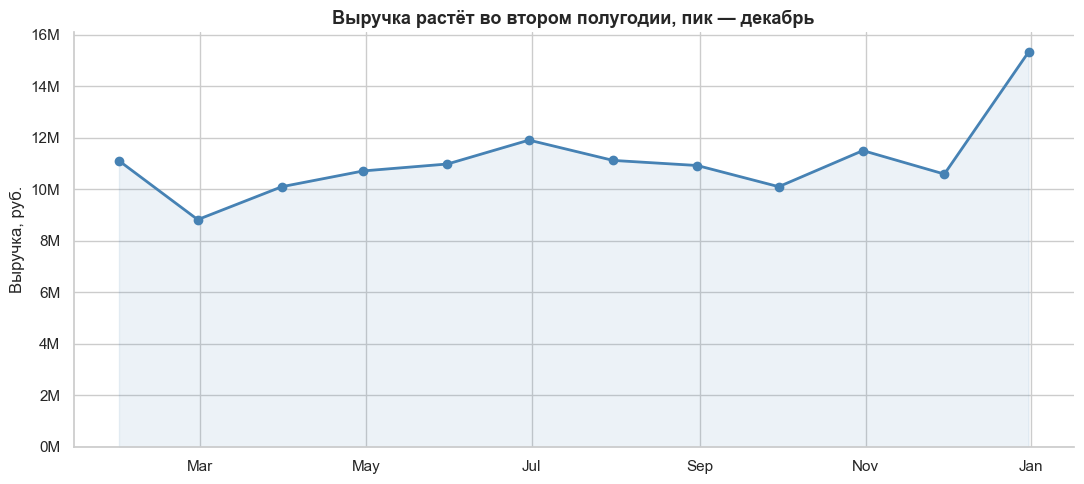

Вывод: декабрь превысил январь на 38%.


In [100]:
monthly = df.set_index('date').resample('ME')['amount'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly['date'], monthly['amount'], marker='o', linewidth=2, color='steelblue')
ax.fill_between(monthly['date'], monthly['amount'], alpha=0.1, color='steelblue')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v/1e6:.0f}M'))
ax.set_title('Выручка растёт во втором полугодии, пик — декабрь', fontsize=13, fontweight='bold')
ax.set_ylabel('Выручка, руб.')
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

growth = (monthly['amount'].iloc[-1] / monthly['amount'].iloc[0] - 1) * 100
print(f"Вывод: декабрь превысил январь на {growth:.0f}%.")

**Вопрос 2: Какие категории и сегменты дают выручку?**

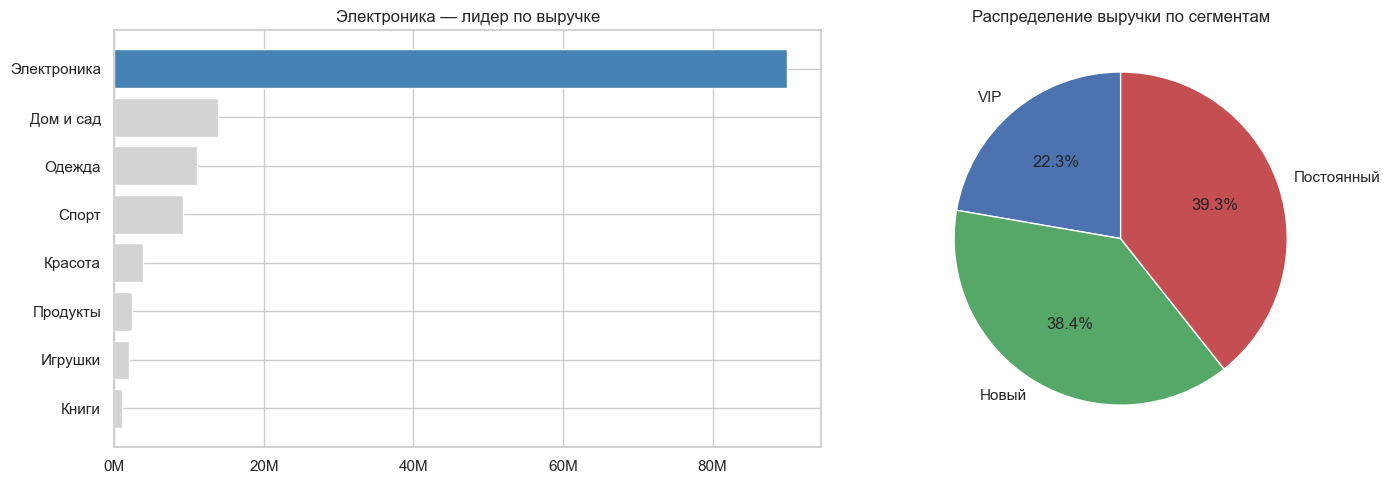

Вывод: Электроника даёт 68% всей выручки.


In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Категории
cat = df.groupby('category')['amount'].sum().sort_values()
colors = ['lightgray'] * len(cat)
colors[-1] = 'steelblue'  # лидера выделяем
axes[0].barh(cat.index, cat.values, color=colors)
axes[0].set_title('Электроника — лидер по выручке')
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v/1e6:.0f}M'))

# Сегменты — доля
seg = df.groupby('segment')['amount'].sum()
axes[1].pie(seg.values, labels=seg.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_title('Распределение выручки по сегментам')

plt.tight_layout()
plt.show()

print(f"Вывод: Электроника даёт {cat.iloc[-1]/cat.sum():.0%} всей выручки.")

**Вопрос 3: Как распределены суммы заказа? Где типичный чек?**

/var/folders/ls/d6mbmny12hb59h29c1bx9rsm0000gn/T/ipykernel_8117/2888247458.py:14: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/artempolyakov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


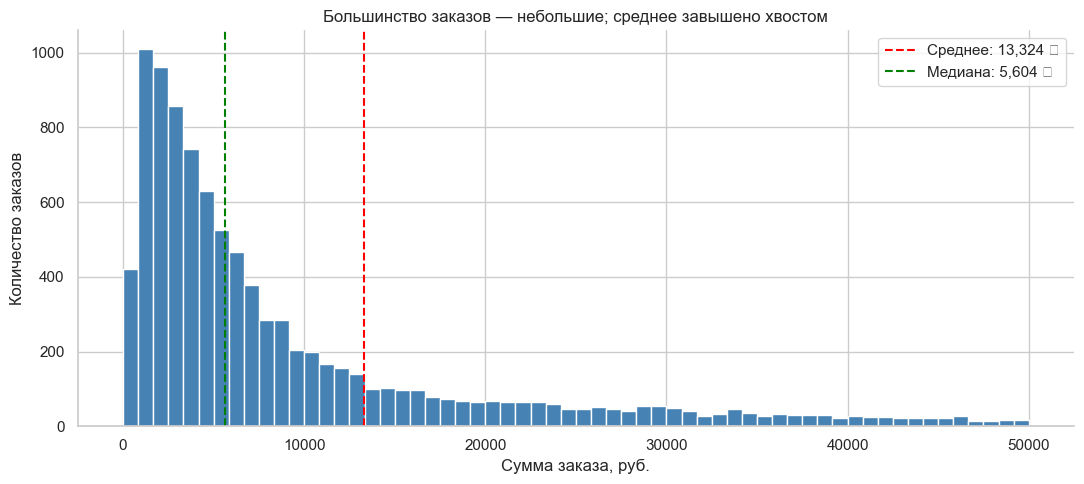

Вывод: медиана (5,604 ₽) ниже среднего (13,324 ₽) — ориентироваться на медиану честнее.


In [102]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df['amount'], bins=60, range=(0, 50000), color='steelblue', edgecolor='white')

mean_v, median_v = df['amount'].mean(), df['amount'].median()
ax.axvline(mean_v, color='red', linestyle='--', label=f'Среднее: {mean_v:,.0f} ₽')
ax.axvline(median_v, color='green', linestyle='--', label=f'Медиана: {median_v:,.0f} ₽')

ax.set_title('Большинство заказов — небольшие; среднее завышено хвостом')
ax.set_xlabel('Сумма заказа, руб.')
ax.set_ylabel('Количество заказов')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Вывод: медиана ({median_v:,.0f} ₽) ниже среднего ({mean_v:,.0f} ₽) — "
      f"ориентироваться на медиану честнее.")

**Вопрос 4 (интерактивный): Связь бюджета и выручки по сегментам**

In [103]:
sample = df.dropna(subset=['ad_budget']).sample(1500, random_state=1)

fig = px.scatter(
    sample, x='ad_budget', y='amount', color='segment',
    opacity=0.6,
    title='Чем больше рекламный бюджет, тем выше сумма заказа',
    labels={'ad_budget': 'Рекламный бюджет, руб.', 'amount': 'Сумма заказа, руб.',
            'segment': 'Сегмент'}
)
fig.show()

fig.write_html('project_scatter.html')
print("Интерактивный график сохранён в project_scatter.html")

Интерактивный график сохранён в project_scatter.html


---

## Итоги

Что ты теперь умеешь на практике:

1. **Подготовить данные** — `groupby`, `agg`, `pivot_table`, `resample` перед построением.
2. **pandas.plot** — быстрый черновик в одну строку.
3. **Matplotlib** — полный контроль: оси, форматирование чисел и дат, аннотации, сетка subplots.
4. **Seaborn** — статистические графики, помня про скрытую агрегацию `barplot`.
5. **Plotly** — интерактив с hover и экспортом в HTML.
6. **Выбор графика** — от вопроса к типу графика.

**Что попробовать дальше:**
- Поменяй параметры в любой ячейке (цвета, `bins`, окно скользящего среднего) и посмотри, что изменится.
- Построй свои разрезы: выручка по каналам, по дням недели, по регионам.
- Собери свой мини-отчёт из 4–5 графиков под собственные вопросы.

**Главное правило, которое стоит запомнить:** сначала вопрос и подготовка данных, потом график. Код графика должен быть простым — если он усложняется, значит, данные ещё не готовы.